# バックテスト doe-004

BAND_VWAP と DD_PROFIT, DD_RATIO の依存性調査

In [1]:
import os
import sys

path_up = os.path.join("..", "..")
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import glob
from collections import defaultdict
from os.path import expanduser

import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import pingouin as pg
import seaborn as sns

from funcs.tse import get_ticker_name_list

## 基本情報

In [3]:
# 実験名
name_doe = "doe-004"

# 実験パラメータ
param_1 = "BAND_VWAP"
param_2 = "DD_PROFIT"
param_3 = "DD_RATIO"

# 銘柄コード
code: str = "9984"
name = get_ticker_name_list([code])[code]
print(f"対象銘柄: {name} ({code})")

# 実験表の読み込み
path_csv = os.path.join("..", f"{name_doe}.csv")
df_doe = pd.read_csv(path_csv)[[param_1, param_2, param_3]]
print(df_doe)

対象銘柄: ソフトバンクグループ (9984)
     BAND_VWAP  DD_PROFIT  DD_RATIO
0            3         10       0.1
1            3         10       0.2
2            3         10       0.3
3            3         10       0.4
4            3         10       0.5
..         ...        ...       ...
184          7         70       0.5
185          7         70       0.6
186          7         70       0.7
187          7         70       0.8
188          7         70       0.9

[189 rows x 3 columns]


## すべての結果を読み込む

In [4]:
path_backtest = os.path.join(expanduser("~"), "MyProjects", "backtest", name_doe)

# 結果の CSV ファイル一覧を抽出してソード
dir_search = os.path.join(path_backtest, f"{code}/*/{code}_result.csv")
list_file: list[str] = sorted(glob.glob(dir_search))

# ファイルをひとつひとつ読み込んでリストに保持
list_df: list[pd.DataFrame] = []
for file in list_file:
    list_df.append(pd.read_csv(file))
# 縦に連結してインデックスを振り直す
df = pd.concat(list_df, axis=0).reset_index(drop=True)
# 年月日の date 列を datetime 型に変換
df["date"] = pd.to_datetime(df["date"])
df.columns

Index(['date', 'run', 'PERIOD_WARMUP', 'BAND_VWAP', 'PERIOD_MA_1',
       'PERIOD_RSI', 'PERIOD_MOM', 'DD_PROFIT', 'DD_RATIO', 'LOSSCUT_1',
       'N_MINUS_MAX', 'trade', 'total'],
      dtype='str')

## 集計

In [5]:
# ユニークな実験 run 数
list_run = sorted(list(set(df["run"])))
# run 毎の集計
list_ser_total: list[pd.Series] = []  # 日別収益
list_ser_cumsum: list[pd.Series] = []  # 累積収益
list_median: list[float] = []  # 収益のメジアン
list_iqr: list[float] = []  # 収益のIQR
list_max: list[float] = []  # 収益の最大
list_min: list[float] = []  # 収益の最小
for run in list_run:
    # 指定した run の対象の列を抽出して "date" 列でソード
    df_run = (
        df[df["run"] == run][["date", "total"]]
        .reset_index(drop=True)
        .sort_values("date")
        .set_index("date")
    )
    # 日別収益
    ser_total = df_run["total"]
    ser_total.name = run
    list_ser_total.append(ser_total)

    # 累積収益
    ser_cumsum = df_run["total"].cumsum()
    ser_cumsum.name = run
    list_ser_cumsum.append(ser_cumsum)

    # メジアン
    v_med = df_run["total"].median()
    list_median.append(v_med)

    # 1. 第1四分位数(Q1)と第3四分位数(Q3)を計算
    v_q1 = df_run["total"].quantile(0.25)
    v_q3 = df_run["total"].quantile(0.75)
    # 2. IQRを計算
    list_iqr.append(v_q3 - v_q1)

    # 最大
    v_max = df_run["total"].max()
    list_max.append(v_max)

    # 最小
    v_min = df_run["total"].min()
    list_min.append(v_min)

In [6]:
print("\n# Daily Total")
df_total = pd.concat(list_ser_total, axis=1)
print(df_total.tail())

print("\n# Cumulative Total")
df_cumsum = pd.concat(list_ser_cumsum, axis=1)
print(df_cumsum.tail())

print("\n# Madian in the period")
ser_median = pd.Series(list_median, name="median")
print(ser_median)

print("\n# IQR in the period")
ser_iqr = pd.Series(list_median, name="iqr")
print(ser_iqr)

print("\n# Max in the period")
ser_max = pd.Series(list_max, name="max")
print(ser_max)

print("\n# Min in the period")
ser_min = pd.Series(list_min, name="min")
print(ser_min)


# Daily Total
               0       1       2        3        4        5        6    \
date                                                                     
2026-03-23  4400.0  3900.0  6100.0   5500.0   4400.0   4000.0   2300.0   
2026-03-24  2100.0  1900.0  1700.0   1700.0   1200.0   5400.0   5400.0   
2026-03-25     0.0     0.0     0.0      0.0      0.0      0.0      0.0   
2026-03-26  3800.0  3600.0  3100.0  22700.0  22000.0  21100.0  20500.0   
2026-03-27  4000.0  5300.0  5300.0  14400.0  14800.0  14400.0  13400.0   

                7        8       9    ...      179     180      181     182  \
date                                  ...                                     
2026-03-23  10000.0    700.0 -1400.0  ...   4000.0  2600.0   1800.0  1000.0   
2026-03-24   5400.0   5400.0  2000.0  ...   5700.0  5700.0   7300.0  6200.0   
2026-03-25      0.0      0.0     0.0  ...  12400.0  9500.0  10300.0  8700.0   
2026-03-26  19800.0  19400.0  2500.0  ...  21100.0  7300.0   5900.0  45

### チャートのサブタイトルとランキング (Top 5)

In [7]:
# 累積収益の最下行（最新日）の収益でランキング
df_cumsum_latest = df_cumsum.tail(1)
dt_latest = df_cumsum_latest.index[0]
subtitle = f"{name_doe}: {param_1} vs. {param_2}, {param_3} on {dt_latest.date()}, {len(df_cumsum)}days"
print(subtitle)

# Top
ser_ranking = df_cumsum_latest.T[dt_latest].sort_values(ascending=False)
list_tops = list(ser_ranking.head(5).index)
print(list_tops)

doe-004: BAND_VWAP vs. DD_PROFIT, DD_RATIO on 2026-03-27, 37days
[150, 151, 159, 160, 177]


In [8]:
ser_cumtotal = df_cumsum_latest.T[dt_latest]
ser_cumtotal.name = "cumtotal"
ser_cumtotal

0        9100.0
1       11500.0
2       20100.0
3       48700.0
4       44100.0
         ...   
184     83700.0
185     81500.0
186    108100.0
187    114300.0
188    113900.0
Name: cumtotal, Length: 189, dtype: float64

### Matplotlib の基本設定

In [9]:
FONT_PATH = "../../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

## 累積収益トレンド

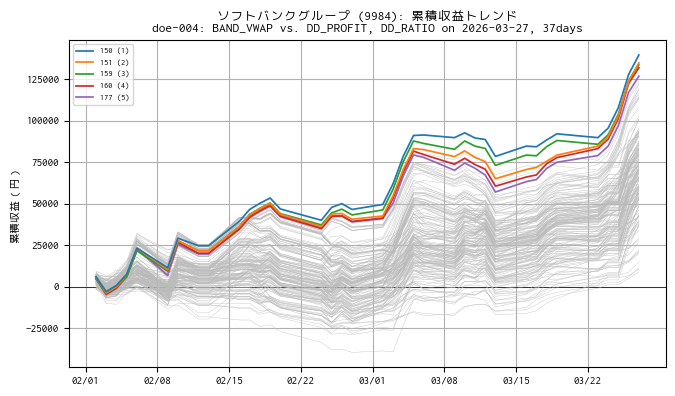

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(f"{name} ({code}): 累積収益トレンド\n{subtitle}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("累積収益（円）")

for colname in list_tops:
    ser = df_cumsum[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_cumsum[colname]
    if colname not in list_tops:
        ax.plot(ser, color="#bbb", linewidth=0.25, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=6)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_cumsum.png"
plt.savefig(name_img)
plt.show()

## 日毎の収益

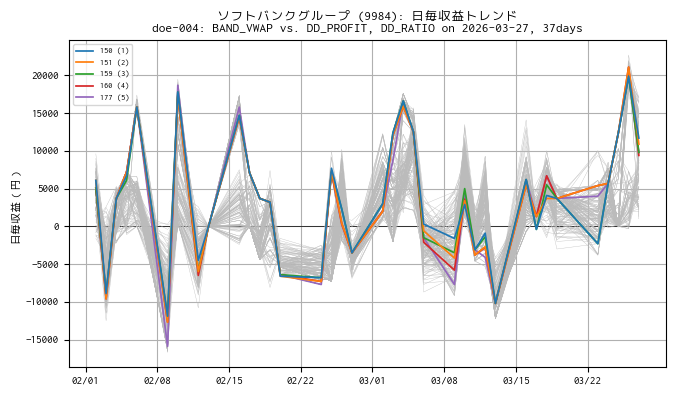

In [11]:
fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(f"{name} ({code}): 日毎収益トレンド\n{subtitle}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("日毎収益（円）")

for colname in list_tops:
    ser = df_total[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_total[colname]
    if colname not in list_tops:
        ax.plot(ser, color="#bbb", linewidth=0.25, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=6)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_total.png"
plt.savefig(name_img)
plt.show()

In [12]:
df_summary = pd.DataFrame(
    {
        "BAND_VWAP": df_doe["BAND_VWAP"],
        "DD_PROFIT": df_doe["DD_PROFIT"],
        "DD_RATIO": df_doe["DD_RATIO"],
        "CumSum": ser_cumtotal,
        "Median": ser_median,
        "IQR": ser_iqr,
        "Max": ser_max,
        "Min": ser_min,
    }
)

(
    df_summary.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary.html", index=False)
)

df_summary

,BAND_VWAP,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
0,3,10,0.1,9100.0,500.0,500.0,5000.0,-5400.0
1,3,10,0.2,11500.0,600.0,600.0,5300.0,-4600.0
2,3,10,0.3,20100.0,400.0,400.0,6200.0,-5500.0
3,3,10,0.4,48700.0,300.0,300.0,22700.0,-5200.0
4,3,10,0.5,44100.0,300.0,300.0,22000.0,-6200.0
...,...,...,...,...,...,...,...,...
184,7,70,0.5,83700.0,3300.0,3300.0,21300.0,-15900.0
185,7,70,0.6,81500.0,1700.0,1700.0,20600.0,-15900.0
186,7,70,0.7,108100.0,3700.0,3700.0,19900.0,-15900.0
187,7,70,0.8,114300.0,3700.0,3700.0,21100.0,-15900.0


In [13]:
row_best = list_tops[0]
df_summary_best = df_summary.iloc[row_best : row_best + 1]
(
    df_summary_best.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary_best.html", index=False)
)
df_summary_best

,BAND_VWAP,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
150,7,30,0.7,139500.0,3700.0,3700.0,19900.0,-11900.0


## 要因効果

In [14]:
ser_cond = df_total.T.stack().copy()
ser_cond.name = "total"
ser_cond.index.names = ["run", "date"]
df_cond = pd.DataFrame(ser_cond).reset_index()
df_cond

,run,date,total
0,0,2026-02-02,2600.0
1,0,2026-02-03,-900.0
2,0,2026-02-04,-1900.0
3,0,2026-02-05,-400.0
4,0,2026-02-06,800.0
...,...,...,...
6988,188,2026-03-23,4000.0
6989,188,2026-03-24,5700.0
6990,188,2026-03-25,12400.0
6991,188,2026-03-26,21100.0


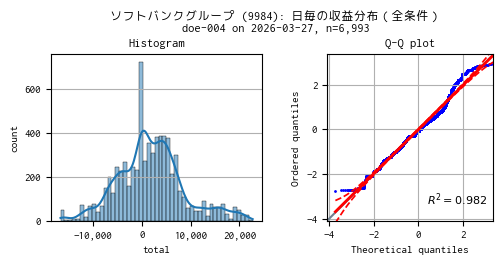

In [15]:
subtitle = f"{name_doe} on {dt_latest.date()}, n={len(df_cond):,d}"

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
sns.set_palette("Set2")

sns.histplot(df_cond["total"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("total")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df_cond["total"], s=1, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

plt.suptitle(
    f"{name} ({code}): 日毎の収益分布（全条件）\n{subtitle}",
    fontsize=9,
)
plt.subplots_adjust(top=0.8, bottom=0.135, wspace=0.2)
plt.savefig(f"{dt_latest.date()}_{code}_hist_qqplot.png")
plt.show()

### 実験 run に対応するパラメータの値を設定（関数）

In [16]:
def add_param(df_doe, df_data, name_param):
    for row in df_doe.index:
        list_index = list(df_data[df_data["run"] == row].index)
        df_data.loc[list_index, name_param] = df_doe.loc[row, name_param]

### パラメータ依存性プロット関数

In [17]:
def plot_dependency(df, name_param, name_img):
    sns.set_palette("pastel")
    fig, ax = plt.subplots(figsize=(6.8, 3))

    ax.set_title(f"{name} ({code}): {name_param} 依存性\n{subtitle}")

    sns.boxplot(data=df, x=name_param, y="total", fliersize=4, ax=ax)
    ax.grid(axis="y")

    plt.tight_layout()
    plt.savefig(name_img)
    plt.show()

### BAND_VWAP

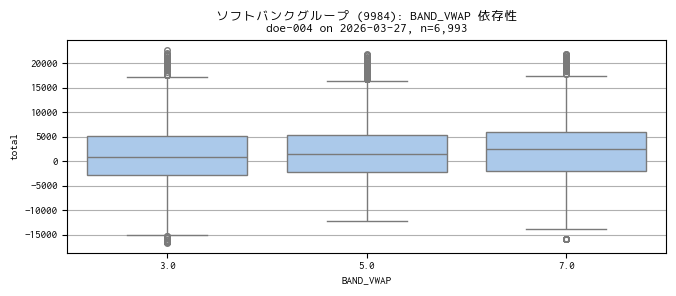

,run,date,total,BAND_VWAP
0,0,2026-02-02,2600.0,3.0
1,0,2026-02-03,-900.0,3.0
2,0,2026-02-04,-1900.0,3.0
3,0,2026-02-05,-400.0,3.0
4,0,2026-02-06,800.0,3.0


In [18]:
name_param = "BAND_VWAP"
df_vwap = df_cond.copy()
add_param(df_doe, df_vwap, name_param)
name_img = f"{dt_latest.date()}_{code}_{name_param}.png"
plot_dependency(df_vwap, name_param, name_img)
df_vwap.head()

### DD_PROFIT

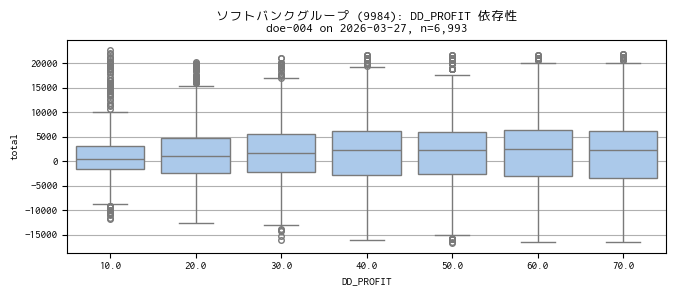

,run,date,total,DD_PROFIT
0,0,2026-02-02,2600.0,10.0
1,0,2026-02-03,-900.0,10.0
2,0,2026-02-04,-1900.0,10.0
3,0,2026-02-05,-400.0,10.0
4,0,2026-02-06,800.0,10.0


In [19]:
name_param = "DD_PROFIT"
df_profit = df_cond.copy()
add_param(df_doe, df_profit, name_param)
name_img = f"{dt_latest.date()}_{code}_{name_param}.png"
plot_dependency(df_profit, name_param, name_img)
df_profit.head()

### DD_RATIO

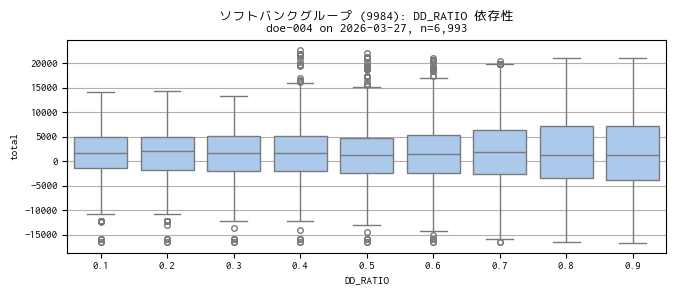

,run,date,total,DD_RATIO
0,0,2026-02-02,2600.0,0.1
1,0,2026-02-03,-900.0,0.1
2,0,2026-02-04,-1900.0,0.1
3,0,2026-02-05,-400.0,0.1
4,0,2026-02-06,800.0,0.1


In [20]:
name_param = "DD_RATIO"
df_ratio = df_cond.copy()
add_param(df_doe, df_ratio, name_param)
name_img = f"{dt_latest.date()}_{code}_{name_param}.png"
plot_dependency(df_ratio, name_param, name_img)
df_ratio.head()